Available columns: ['averageInteractionsPerCrossing', 'p_Rhad1', 'p_Rhad', 'p_f3', 'p_weta2', 'p_Rphi', 'p_Reta', 'p_Eratio', 'p_f1', 'p_TRTPID']

Energy-related columns: ['pX_core57cellsEnergyCorrection', 'pX_maxEcell_energy', 'pX_neflowisolcoreConeEnergyCorrection', 'pX_topoetconecoreConeEnergyCorrection', 'p_Truth_Energy']
Electron-related columns: ['p_Truth_isElectron']

Using energy column: p_Truth_Energy
Training electrons: 30240, Validation electrons: 7560
Number of features: 140


Computing CPI (MAE): 100%|██████████| 140/140 [29:28<00:00, 12.63s/feature]


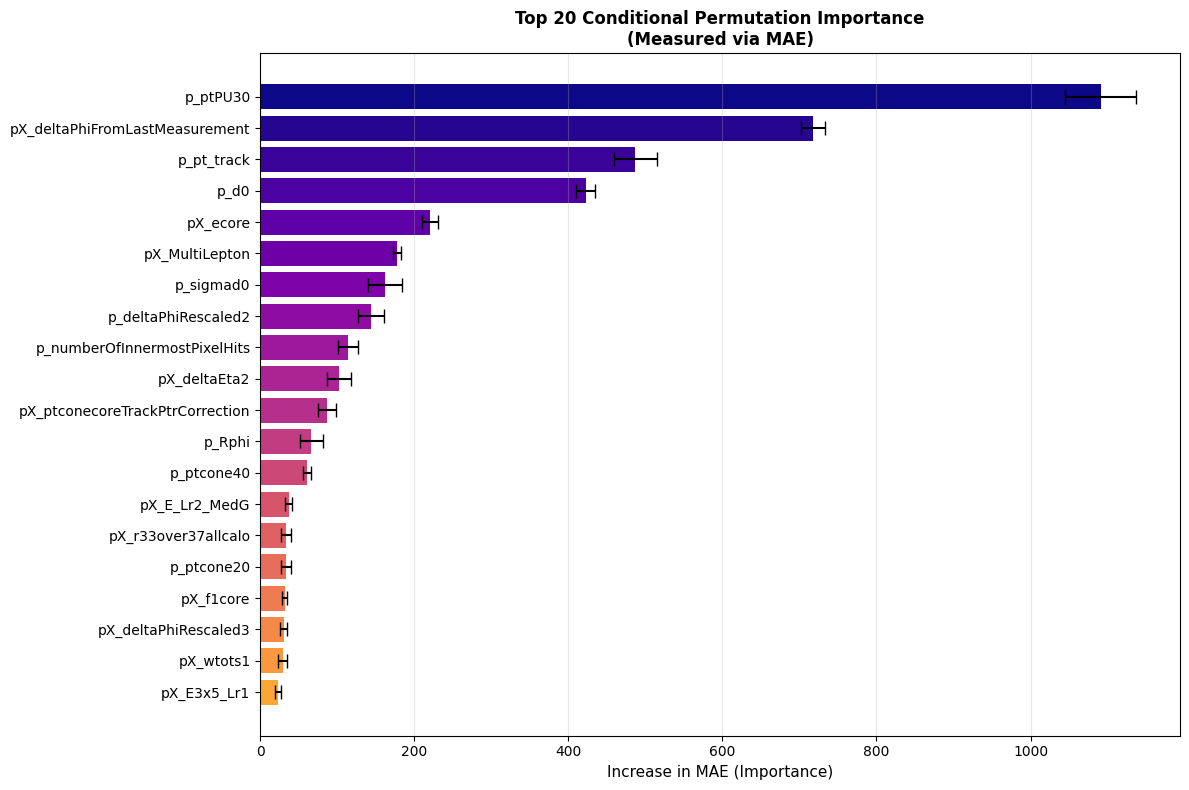

Baseline MAE on validation set: 6824.578768


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from tqdm import tqdm

# --- Data Loading and Initial Prep ---
reg_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')

# Check column names
print("Available columns:", reg_train_data.columns.tolist()[:10])
print("\nEnergy-related columns:", [col for col in reg_train_data.columns if 'energy' in col.lower()])
print("Electron-related columns:", [col for col in reg_train_data.columns if 'electron' in col.lower()])

# Filter for electrons only
electrons_mask = reg_train_data['p_Truth_isElectron'] == 1
reg_train_electrons = reg_train_data[electrons_mask].copy()

# Use the correct energy column name
energy_col = 'p_Truth_Energy' if 'p_Truth_Energy' in reg_train_electrons.columns else 'p_truth_Energy'
target = reg_train_electrons[energy_col]
variables = reg_train_electrons.drop(columns=['p_Truth_isElectron', energy_col])

reg_test_data = pd.read_csv('../Data/AppML_InitialProject_test_regression.csv')

X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42
)

print(f"\nUsing energy column: {energy_col}")
print(f"Training electrons: {len(X_train)}, Validation electrons: {len(X_val)}")
print(f"Number of features: {len(X_train.columns)}")

# --- Train Main Model ---
model = XGBRegressor(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.6,
    colsample_bytree=0.85,
    gamma=2.4,
    min_child_weight=7,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Conditional Permutation Importance for Regression ---
def conditional_permutation_importance_regression(model, X_train, X_val, y_val, features=None, n_repeats=10, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    
    # Use MAE as the baseline metric (lower is better)
    preds_val = model.predict(X_val)
    baseline_mae = mean_absolute_error(y_val, preds_val)
    
    if features is None:
        features = X_train.columns
        
    records = []
    
    for feature in tqdm(features, desc='Computing CPI (MAE)', unit='feature'):
        other_cols = [c for c in X_train.columns if c != feature]

        # Fit regressor to model feature dependencies
        reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1)
        reg.fit(X_train[other_cols], X_train[feature])

        # Calculate residuals on TRAIN
        preds_train = reg.predict(X_train[other_cols])
        residuals = (X_train[feature] - preds_train).to_numpy()
        
        # Calculate predicted base for VAL
        preds_val_base = reg.predict(X_val[other_cols])
        
        losses = []
        for _ in range(n_repeats):
            # Sample residuals and reconstruct feature
            sampled_resid = rng.choice(residuals, size=len(preds_val_base), replace=True)
            Xc = X_val.copy()
            Xc[feature] = preds_val_base + sampled_resid
            
            # Measure how much the MAE increases (higher increase = more important)
            perm_preds = model.predict(Xc)
            perm_mae = mean_absolute_error(y_val, perm_preds)
            losses.append(perm_mae - baseline_mae)
            
        records.append((feature, float(np.mean(losses)), float(np.std(losses))))

    imp_df = pd.DataFrame(records, columns=['feature', 'importance', 'std']).sort_values('importance', ascending=False)
    return imp_df

# Run importance
importance_df = conditional_permutation_importance_regression(
    model, X_train, X_val, y_val, features=X_train.columns, n_repeats=10
)

# --- Visualization ---
top_n = 20
top_features = importance_df.head(top_n)
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=plt.cm.plasma(np.linspace(0, 0.8, top_n)), capsize=5)
plt.xlabel('Increase in MAE (Importance)', fontsize=11)
plt.title(f'Top {top_n} Conditional Permutation Importance\n(Measured via MAE)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Baseline MAE on validation set: {mean_absolute_error(y_val, model.predict(X_val)):.6f}')

In [3]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train)
train_mae_top = mean_absolute_error(y_train, model_top.predict(X_train_top))
val_mae_top = mean_absolute_error(y_val, model_top.predict(X_val_top))

print(f'Train MAE with top features: {train_mae_top:.6f}')
print(f'Validation MAE with top features: {val_mae_top:.6f}')
print(f'Number of features selected: {len(top_feature_names)}')

Train MAE with top features: 4453.815964
Validation MAE with top features: 7392.630638
Number of features selected: 20


In [4]:
# Hyperparameter tuning for Regression XGBoost on the reduced top-feature set
from skopt import BayesSearchCV
from skopt.space import Real, Integer

search_space = {
    'n_estimators': Integer(2300, 3300),
    'max_depth': Integer(5, 20),
    'learning_rate': Real(0.025, 0.075, prior='log-uniform'),
    'subsample': Real(0.4, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(1.5, 4.0),
    'min_child_weight': Integer(2, 20)
}

bayes_search = BayesSearchCV(
    estimator=XGBRegressor(
        eval_metric='mae', 
        random_state=42, 
        n_jobs=-1,
        tree_method='hist'
    ),
    search_spaces=search_space,
    n_iter=5,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

bayes_search.fit(X_train_top, y_train)

print(f'Best CV score (neg MAE): {bayes_search.best_score_:.6f}')
print(f'Best parameters: {bayes_search.best_params_}')

best_model = bayes_search.best_estimator_
val_mae_tuned = mean_absolute_error(y_val, best_model.predict(X_val_top))
print(f'Validation MAE after Bayesian tuning: {val_mae_tuned:.6f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best CV score (neg MAE): -7190.687182
Best parameters: OrderedDict({'colsample_bytree': 0.7224162561505759, 'gamma': 3.7968063041734426, 'learning_rate': 0.02805243352902679, 'max_depth': 11, 'min_child_weight': 5, 'n_estimators': 2754, 'subsample': 0.49326883243032604})
Validation MAE after Bayesian tuning: 7312.604635


In [9]:
# Compute XGBoost parameter count (approx. number of leaf weights) and validation metrics
import numpy as np

param_count = None
val_mae = None
val_rmse = None

if 'best_model' in globals():
    try:
        booster = best_model.get_booster()
        trees = booster.get_dump(with_stats=False)
        leaf_count = 0
        for t in trees:
            for line in t.splitlines():
                if 'leaf=' in line:
                    leaf_count += 1
        param_count = leaf_count
    except Exception as e:
        print('Could not extract booster dump:', e)

if 'best_model' in globals() and 'X_val_top' in globals() and 'y_val' in globals():
    try:
        val_preds = best_model.predict(X_val_top)
        val_mae = float(mean_absolute_error(y_val, val_preds))
        val_rmse = float(np.sqrt(mean_squared_error(y_val, val_preds)))
    except Exception as e:
        print('Could not compute validation metrics:', e)

print('Approx parameter count (leaf weights):', param_count)
print('Validation MAE (best_model on X_val_top):', val_mae)
print('Validation RMSE (best_model on X_val_top):', val_rmse)

Approx parameter count (leaf weights): 1015078
Validation MAE (best_model on X_val_top): 239.70037373233146
Validation RMSE (best_model on X_val_top): 358.50197173648314


In [6]:
# Print tuned best_model parameters
if 'best_model' in globals():
    params = best_model.get_params()
    keys = ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree','gamma','min_child_weight']
    print('Best model hyperparameters:')
    for k in keys:
        print(f"{k}: {params.get(k)}")
else:
    print('best_model not available in notebook globals.')

Best model hyperparameters:
n_estimators: 2754
max_depth: 11
learning_rate: 0.02805243352902679
subsample: 0.49326883243032604
colsample_bytree: 0.7224162561505759
gamma: 3.7968063041734426
min_child_weight: 5


In [7]:
# Train best model on full training data with top features and export
from pathlib import Path

X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)

# Load test data and extract top features
X_test = reg_test_data[top_feature_names]

# Get energy predictions (in GeV, as in training)
test_predictions = best_model.predict(X_test)

# Define output paths and filenames
solution_name = "XGBoost2"
name = "BenjaminSiddique"
output_dir = Path('../Regression/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions (in GeV)
predictions_filename = f"Regression_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

# Export chosen features
varlist_filename = f"Regression_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")

print(f'Predictions exported to: {predictions_filepath}')
print(f'Variable list exported to: {varlist_filepath}')
print(f'Total entries: {len(test_predictions)}')

Predictions exported to: ..\Regression\Output\Regression_BenjaminSiddique_XGBoost2.csv
Variable list exported to: ..\Regression\Output\Regression_BenjaminSiddique_XGBoost2_VariableList.csv
Total entries: 40000
